In [1]:
import os
os.environ["TF_KERAS"] = "1"  # ← 要在所有 import 之前設定

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import transformers as ppb
import tensorflow as tf

# 統一用 tf.keras，不要用 from tensorflow.keras import
keras = tf.keras
layers = tf.keras.layers

import matplotlib.pyplot as plt

c:\Users\a2274\anaconda3\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#參數設置區

#資料集、模型選擇參數設置區
dataSet = 'Final_XSS_Dataset' #選項有 'XSS_dataset'、'HttpParamsDataset'、'PortSwigger_XSSDataSet'、'XSSed_CSIC2010'、'Final_XSS_Dataset'
modelType = 'tinyBERT' #選項有 'BERT'、'DistilBERT'、'tinyBERT'

#I/O參數設置區

if dataSet == 'XSS_dataset':
  dataSetPath = './TrainingData/DataSet/XSS_dataset.csv'
elif dataSet == 'HttpParamsDataset':
  dataSetPath = './TrainingData/DataSetOfHttpParamsDataset/payload_train.csv'
elif dataSet == 'PortSwigger_XSSDataSet':
  dataSetPath = './TrainingData/Final_PortSwigger_XSSDataset(資料集內容待驗證)/PortSwigger_XSSDataSet.csv'
elif dataSet == 'XSSed_CSIC2010':
  dataSetPath = './TrainingData/Final_XSSed_CSIC2010FromKaggle(資料集內容待驗證)/XSSed_CSIC2010.csv'
elif dataSet == 'Final_XSS_Dataset':
  dataSetPath = '../res/train_data/xss_dataset.csv' #Final_XSSDataSet(資料集內容待驗證)/Final_XSS_dataset(Train).csv'

In [3]:
#載入資料集
df = pd.read_csv( dataSetPath, header = None )

In [4]:
#Loading Pre-trained Model

#Loading Pre-trained BERT Model:
if modelType == 'DistilBERT':
  model_class, tokenizer_class, pretrained_weights = ( ppb.DistilBertModel, ppb.DistilBertTokenizer, 'distilbert-base-uncased' )
elif modelType == 'BERT':
  model_class, tokenizer_class, pretrained_weights = ( ppb.BertModel, ppb.BertTokenizer, 'bert-base-uncased' )
elif modelType == 'tinyBERT': #此條件式內部的內容皆為GPT生成的，目前正在測試相關功能
  tokenizer = ppb.BertTokenizer.from_pretrained("prajjwal1/bert-tiny")
  bert_layer = ppb.TFBertModel.from_pretrained( "prajjwal1/bert-tiny", from_pt = True ) 

# Load pretrained model/tokenizer
if modelType != 'tinyBERT':
    tokenizer = tokenizer_class.from_pretrained( pretrained_weights )
    model = model_class.from_pretrained( pretrained_weights )

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'bert.embeddings.position_ids', 'cls.seq_relationship.weight', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClas

In [5]:
#Debugging Cell (You can use this cell to debug if you encounter any problems in tokenization)

index = 0

for element in df[0]:
    if type( element ) != type( 'str' ):
        print( 'In index ', index, ': The type of element is ', type( element ) )

    index = index + 1

In [6]:
#Tokenization
# tokenized = df[0].apply( ( lambda x: tokenizer.encode( x, add_special_tokens = True ) ) ) #Stable and crediable method
tokenized = df[0].apply( ( lambda x: tokenizer.encode( x, add_special_tokens = True, truncation = True, max_length = 256 ) ) ) # New and unstable method 

In [7]:
#Padding
padded = []
labels = []
index = 0
maxLen = 0

for token in tokenized.values:

  if len( token ) > maxLen:
    maxLen = len( token )

for token in tokenized.values:
    
  while len( token ) <= maxLen:

    if len( token ) < maxLen:
      token.append( 0 )

    else:
      padded.append( token )

      if dataSet == 'HttpParamsDataset' :
        labels.append( df.loc[ index, 3 ] )

      else:
        labels.append( df.loc[ index, 1 ] )
          
      break

  index = index + 1

padded = np.array( padded )
print( type( padded ) )
print( 'The maxium length is ', maxLen )

<class 'numpy.ndarray'>
The maxium length is  256


In [8]:
#如果是使用HttpParamsDataset資料集，對資料集的label作一點處理
if dataSet == 'HttpParamsDataset' : 
  print( 'The length of labels is ', len(labels) ) #Debug用

  templabels = [] #將label從字串轉換成整數用，具體作法是先從label list中取出一個label，將其轉換成整數後存進此list中。
                  #當所有label都轉成整數並存進此list後會再將label list重新指向此list。

  for index in range( 0, len( labels ), 1 ):

    if labels[index] == 'norm':
      templabels.append( 0 )

    elif labels[index] == 'anom':
      templabels.append( 1 )

  print( 'The length of templabels is ', len(templabels) ) #Debug用
  labels = templabels

In [9]:
#Debug(印label)
print( labels )

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 

In [20]:
from transformers import TFBertModel

class BertBiLSTMModel(tf.keras.Model):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert   = TFBertModel.from_pretrained(model_name, from_pt=True)
        self.bilstm = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(128, return_sequences=False)
        )
        self.concat     = tf.keras.layers.Concatenate()
        self.classifier = tf.keras.layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        input_ids      = inputs[0]
        attention_mask = inputs[1]

        bert_outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask, training=training)
        sequence_output = bert_outputs.last_hidden_state  # [batch, seq_len, hidden]
        pooler_output   = bert_outputs.pooler_output      # [batch, hidden]

        bilstm_output = self.bilstm(sequence_output)               # [batch, 256]
        merged        = self.concat([pooler_output, bilstm_output]) # [batch, hidden+256]
        return self.classifier(merged)

In [21]:
MODEL_NAME = "prajjwal1/bert-tiny"
MAX_LEN = 256


# 建立模型
model = BertBiLSTMModel(model_name=MODEL_NAME, num_classes=2)

# 先跑一次 dummy input 讓模型 build
dummy_ids  = tf.zeros((2, MAX_LEN), dtype=tf.int32)
dummy_mask = tf.ones((2, MAX_LEN),  dtype=tf.int32)
_ = model([dummy_ids, dummy_mask])

model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'bert.embeddings.position_ids', 'cls.seq_relationship.weight', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the 

Model: "bert_bi_lstm_model_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (2, 256)               │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate (Concatenate)       │ (2, 384)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (2, 2)                 │           770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,938 (1.01 MB)

 Trainable params: 263,938 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#設置編譯參數
optimizer = tf.keras.optimizers.Adam( learning_rate = 0.0001 ) #這裡用的可能不是論文裡用的optimizer
loss = 'BinaryCrossentropy' #這裡用的可能不是論文裡用的loss function，
                            #目前考慮採用的loss function有
                            #  1) 'BinaryCrossentropy'
                            #  2) 'categorical_crossentropy'

#編譯model
model.compile( 
    optimizer = optimizer,
    loss = loss,
    metrics = [ 'accuracy', tf.keras.metrics.Recall() ] #這裡用的可能不是論文裡用的metrics 
)

In [24]:
#處理訓練與驗證資料並切割訓練資料集和驗證資料集
from tensorflow.keras.utils import to_categorical
#處理訓練與驗證資料
labels = to_categorical( labels )

#切割訓練資料集和驗證資料集(此切法可能和論文裡的切法不同)
trainingData, validData, trainingLabel, validLabel = train_test_split( padded, np.array( labels ), test_size = 0.1 , shuffle = True , stratify=labels) #stratify=labels

#查看結果
print( 'Training data and label : ', trainingData.shape, trainingLabel.shape )
print( '驗證資料與label : ', validData.shape, validLabel.shape )

Training data and label :  (12317, 256) (12317, 2)
驗證資料與label :  (1369, 256) (1369, 2)


In [ ]:
#訓練參數設置(此配置可能跟論文的配置不同)
epoch = 10
batchSize = 128

In [26]:
#Masking
training_attention_mask = np.where( trainingData != 0, 1, 0 )
valid_attention_mask = np.where( validData != 0, 1, 0 )

In [27]:
'''
#開始訓練
callbacksList = [
    #以下這個callback為在每個週期結束後若val_loss有改善，則把當下的模型給存起來
    #簡單來說這個callback的目的就是希望可以把val_loss最好的那個週期的模型給存起來
    keras.callbacks.ModelCheckpoint( 
        filepath = "BestModel_TinyBERT.keras", #存檔的路徑及檔名
        monitor = "val_loss", #當val_loss有改善時才會儲存模型，別忘了若寫了這一行程式碼
                              #則一定要在此callback裡面也加上save_best_only = True這一
                              #行程式碼才行
        save_best_only = True, 
    )
]
'''

history = model.fit(
              [ trainingData, training_attention_mask ], #訓練資料，貌似需為NumPy陣列或DataSet物件
              trainingLabel, #訓練資料的label，貌似需為NumPy陣列或DataSet物件
              epochs = epoch,
              batch_size = batchSize, 
              #callbacks = callbacksList,
              validation_data = ( [ validData, valid_attention_mask] , validLabel ) #驗證資料及其label需為NumPy陣列或DataSet物件
          ) 

best_epoch = np.argmin(history.history['val_loss']) + 1  # 加1 是因為 epoch 編號從1開始
print(f"Best epoch is: {best_epoch}")

Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 86s 847ms/step - accuracy: 0.7460 - loss: 0.5697 - recall: 0.7460 - val_accuracy: 0.9810 - val_loss: 0.0636 - val_recall: 0.9810
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 85s 875ms/step - accuracy: 0.9763 - loss: 0.0856 - recall: 0.9763 - val_accuracy: 0.9869 - val_loss: 0.0381 - val_recall: 0.9869
Epoch 3/10
26/97 ━━━━━━━━━━━━━━━━━━━━ 1:00 855ms/step - accuracy: 0.9864 - loss: 0.0480 - recall: 0.9864

KeyboardInterrupt: 

In [ ]:
final_X = padded  
final_attention_mask = np.where(final_X != 0, 1, 0)
final_y = np.array(labels)  

model.fit(
    [final_X, final_attention_mask],
    final_y,
    epochs=best_epoch,  
    batch_size=batchSize
)

filepath = "BestModel_TinyBERT_1.keras"
model.save(filepath)


Epoch 1/6
214/214 [==============================] - 30s 138ms/step - loss: 0.0010 - accuracy: 0.9997 - recall: 0.9997
Epoch 2/6
214/214 [==============================] - 30s 138ms/step - loss: 7.6488e-04 - accuracy: 0.9998 - recall: 0.9998
Epoch 3/6
214/214 [==============================] - 30s 142ms/step - loss: 6.2512e-05 - accuracy: 1.0000 - recall: 1.0000
Epoch 4/6
214/214 [==============================] - 31s 143ms/step - loss: 5.1754e-05 - accuracy: 1.0000 - recall: 1.0000
Epoch 5/6
214/214 [==============================] - 31s 143ms/step - loss: 5.5826e-05 - accuracy: 1.0000 - recall: 1.0000
Epoch 6/6
214/214 [==============================] - 31s 143ms/step - loss: 2.9180e-05 - accuracy: 1.0000 - recall: 1.0000


In [ ]:
results = model.evaluate([final_X, final_attention_mask], final_y, batch_size=batchSize)
print(results)

preds = model.predict([final_X, final_attention_mask], batch_size=batchSize)
pred_labels = preds.argmax(axis=1)  # 將機率轉成預測類別

from sklearn.metrics import accuracy_score, f1_score

true_labels = final_y.argmax(axis=1)  # one-hot 轉整數標籤
print("Accuracy (sklearn):", accuracy_score(true_labels, pred_labels))
print("F1 score (weighted):", f1_score(true_labels, pred_labels, average='weighted'))

214/214 [==============================] - 12s 53ms/step - loss: 1.4443e-05 - accuracy: 1.0000 - recall: 1.0000
[1.4443023246712983e-05, 1.0, 1.0]
214/214 [==============================] - 12s 50ms/step
Accuracy (sklearn): 1.0
F1 score (weighted): 1.0


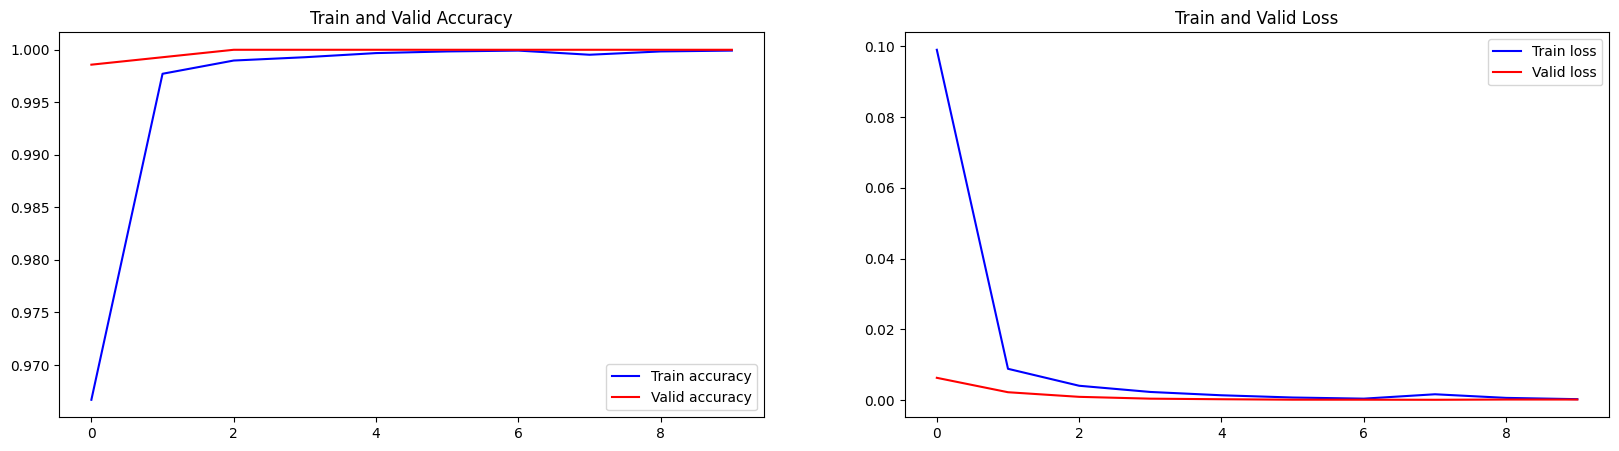

In [ ]:
# Plot training and validating accuracy and loss curve
h = history.history
epochs = range( len ( h['loss'] ) )

plt.figure( figsize = ( 20, 5 ) )
ax = plt.subplot( 1, 2, 1 )
ax.set_title( 'Train and Valid Accuracy' )
plt.plot( epochs, h['accuracy'], 'b', label='Train accuracy' )
plt.plot( epochs, h['val_accuracy'], 'r', label='Valid accuracy' )
plt.legend()

ax = plt.subplot(1, 2, 2)
ax.set_title('Train and Valid Loss')
plt.plot(epochs, h['loss'], 'b', label='Train loss')
plt.plot(epochs, h['val_loss'], 'r', label='Valid loss')
plt.legend()

plt.savefig(f'Train_Valid_ACCandLOSS_Tiny_BERT.png')

plt.show()